In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("C:\\Users\\Lenovo\\Desktop\\ai4i2020.csv")
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [3]:
df.shape

(10000, 14)

In [4]:
df.columns

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [6]:
df['Machine failure'].value_counts()

Machine failure
0    9661
1     339
Name: count, dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [9]:
df['Type'].value_counts()

Type
L    6000
M    2997
H    1003
Name: count, dtype: int64

In [10]:
pd.crosstab(df['Type'], df['Machine failure'])

Machine failure,0,1
Type,,
H,982,21
L,5765,235
M,2914,83


In [11]:
df.groupby('Machine failure')[[
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]'
]].mean()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
Machine failure,,,,,
0,299.973999,309.995570,1540.260014,39.629655,106.693717
1,300.886431,310.290265,1496.486726,50.168142,143.781711


In [12]:
df.corr(numeric_only=True)

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
UDI,1.000000,0.117428,0.324428,-0.006615,0.003207,-0.010702,-0.022892,0.009154,-0.022215,-0.023557,-0.000990,-0.005954
Air temperature [K],0.117428,1.000000,0.876107,0.022670,-0.013778,0.013853,0.082556,0.009955,0.137831,0.003470,0.001988,0.017688
Process temperature [K],0.324428,0.876107,1.000000,0.019277,-0.014061,0.013488,0.035946,0.007315,0.056933,-0.003355,0.004554,0.022279
Rotational speed [rpm],-0.006615,0.022670,0.019277,1.000000,-0.875027,0.000223,-0.044188,0.010389,-0.121241,0.123018,-0.104575,-0.013088
Torque [Nm],0.003207,-0.013778,-0.014061,-0.875027,1.000000,-0.003093,0.191321,-0.014662,0.142610,0.083781,0.183465,0.016136
Tool wear [min],-0.010702,0.013853,0.013488,0.000223,-0.003093,1.000000,0.105448,0.115792,-0.001287,-0.009334,0.155894,0.011326
Machine failure,-0.022892,0.082556,0.035946,-0.044188,0.191321,0.105448,1.000000,0.362904,0.575800,0.522812,0.531083,0.004516
TWF,0.009154,0.009955,0.007315,0.010389,-0.014662,0.115792,0.362904,1.000000,-0.007332,0.008577,0.038243,0.030970
HDF,-0.022215,0.137831,0.056933,-0.121241,0.142610,-0.001287,0.575800,-0.007332,1.000000,0.018443,0.046396,-0.004706
PWF,-0.023557,0.003470,-0.003355,0.123018,0.083781,-0.009334,0.522812,0.008577,0.018443,1.000000,0.115836,-0.004273


In [13]:
df_ml = df.drop(columns=['UDI', 'Product ID', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF'])
df_ml.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
0,M,298.1,308.6,1551,42.8,0,0
1,L,298.2,308.7,1408,46.3,3,0
2,L,298.1,308.5,1498,49.4,5,0
3,L,298.2,308.6,1433,39.5,7,0
4,L,298.2,308.7,1408,40.0,9,0


In [14]:
X = df_ml.drop(columns=['Machine failure'])
y = df_ml['Machine failure']
print(X.shape)
print(y.shape)

(10000, 6)
(10000,)


In [15]:
X = pd.get_dummies(X, columns=['Type'], drop_first=True)
X.head()
X.shape

(10000, 7)

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (8000, 7)
X_test: (2000, 7)
y_train: (8000,)
y_test: (2000,)


In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(X_train_scaled.shape)
print(X_test_scaled.shape)

(8000, 7)
(2000, 7)


In [18]:
from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model_lr.fit(X_train_scaled, y_train)

y_pred = model_lr.predict(X_test_scaled)

print(y_pred[:20])

[1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [19]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9675

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      1932
           1       0.64      0.10      0.18        68

    accuracy                           0.97      2000
   macro avg       0.80      0.55      0.58      2000
weighted avg       0.96      0.97      0.96      2000


Confusion Matrix:
[[1928    4]
 [  61    7]]


In [20]:
from sklearn.linear_model import LogisticRegression

model_lr_balanced = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

model_lr_balanced.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [21]:
y_pred_balanced = model_lr_balanced.predict(X_test_scaled)

In [22]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred_balanced))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_balanced))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_balanced))

Accuracy: 0.8245

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.82      0.90      1932
           1       0.14      0.82      0.24        68

    accuracy                           0.82      2000
   macro avg       0.57      0.82      0.57      2000
weighted avg       0.96      0.82      0.88      2000


Confusion Matrix:
[[1593  339]
 [  12   56]]


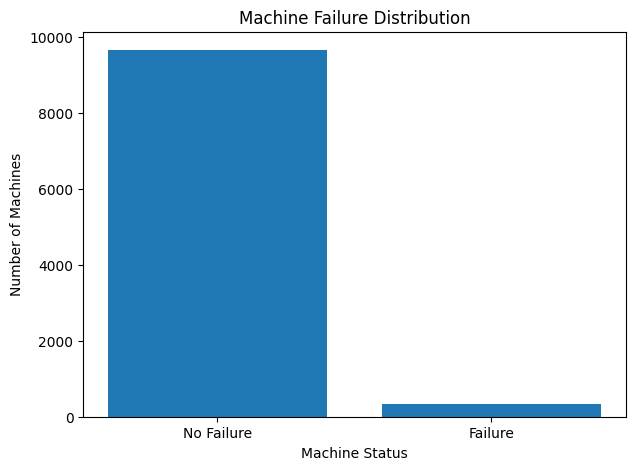

In [23]:
import matplotlib.pyplot as plt

failure_counts = df['Machine failure'].value_counts()

plt.figure(figsize=(7, 5))
plt.bar(
    ['No Failure', 'Failure'],
    [failure_counts[0], failure_counts[1]]
)

plt.title('Machine Failure Distribution')
plt.xlabel('Machine Status')
plt.ylabel('Number of Machines')

plt.show()

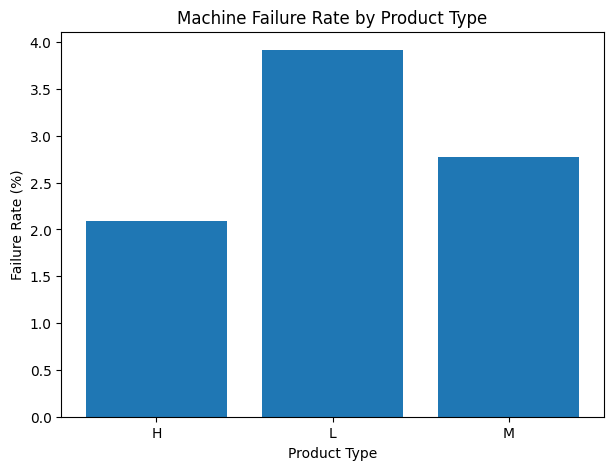

In [24]:
failure_rate = df.groupby('Type')['Machine failure'].mean() * 100

plt.figure(figsize=(7, 5))
plt.bar(failure_rate.index, failure_rate.values)

plt.title('Machine Failure Rate by Product Type')
plt.xlabel('Product Type')
plt.ylabel('Failure Rate (%)')

plt.show()

<Figure size 700x500 with 0 Axes>

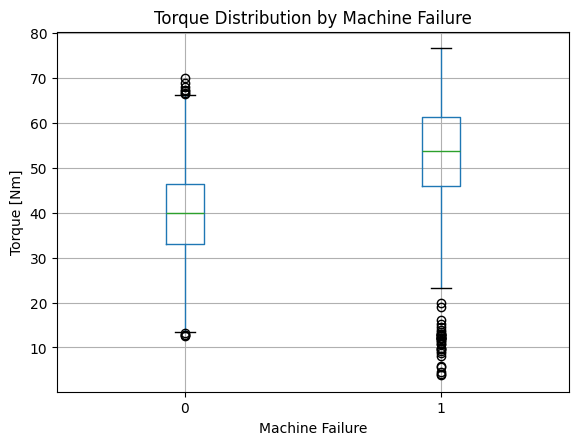

In [25]:
plt.figure(figsize=(7, 5))

df.boxplot(
    column='Torque [Nm]',
    by='Machine failure'
)

plt.title('Torque Distribution by Machine Failure')
plt.suptitle('')
plt.xlabel('Machine Failure')
plt.ylabel('Torque [Nm]')

plt.show()

<Figure size 700x500 with 0 Axes>

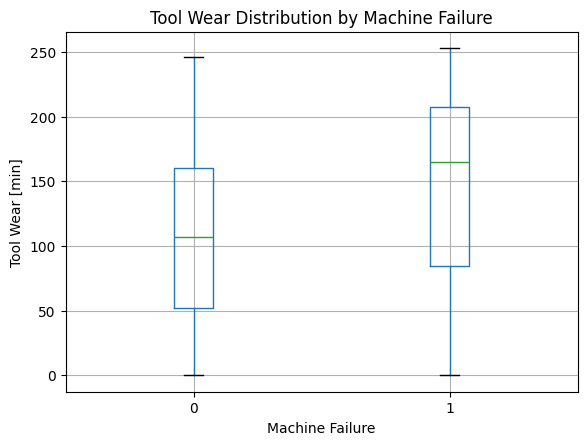

In [26]:
plt.figure(figsize=(7, 5))

df.boxplot(
    column='Tool wear [min]',
    by='Machine failure'
)

plt.title('Tool Wear Distribution by Machine Failure')
plt.suptitle('')
plt.xlabel('Machine Failure')
plt.ylabel('Tool Wear [min]')

plt.show()

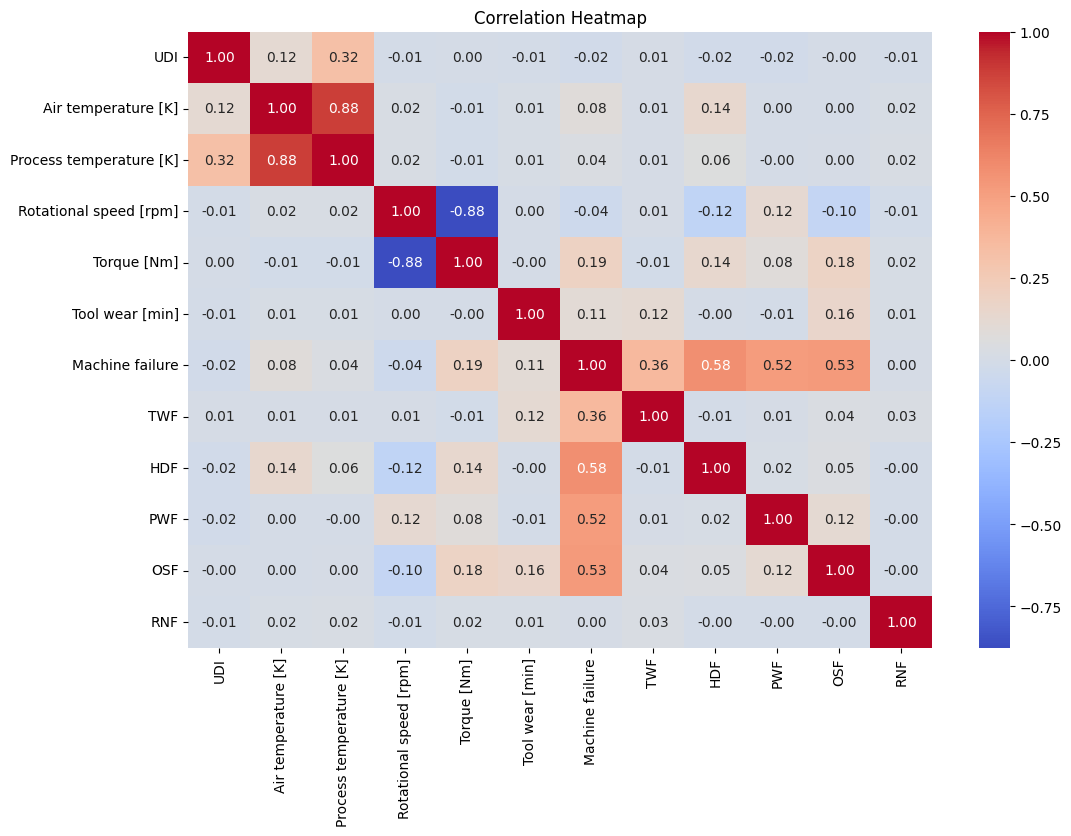

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

corr = df.select_dtypes(include='number').corr()

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')
plt.show()

In [28]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)
print("Random Forest")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Random Forest
Accuracy: 0.9805

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1932
           1       0.91      0.47      0.62        68

    accuracy                           0.98      2000
   macro avg       0.95      0.73      0.81      2000
weighted avg       0.98      0.98      0.98      2000


Confusion Matrix:
[[1929    3]
 [  36   32]]


In [29]:
import pandas as pd

feature_importance = pd.Series(
    model_rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(feature_importance)

Torque [Nm]                0.311137
Rotational speed [rpm]     0.290771
Tool wear [min]            0.207939
Air temperature [K]        0.105084
Process temperature [K]    0.067814
Type_L                     0.009703
Type_M                     0.007552
dtype: float64


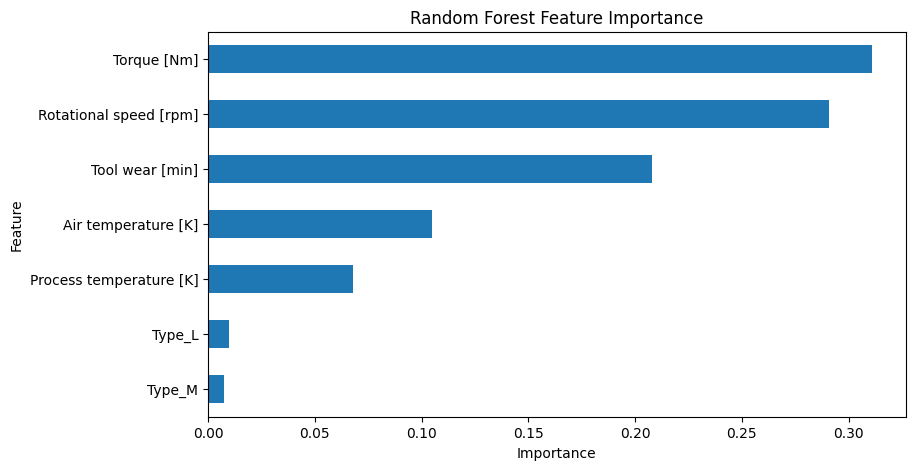

In [30]:
plt.figure(figsize=(9, 5))

feature_importance.sort_values().plot(kind='barh')

plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')

plt.show()

In [31]:
from sklearn.ensemble import GradientBoostingClassifier

model_gb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

model_gb.fit(X_train, y_train)
y_pred_gb = model_gb.predict(X_test)
print("Gradient Boosting")
print("Accuracy:", accuracy_score(y_test, y_pred_gb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_gb))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_gb))

Gradient Boosting
Accuracy: 0.986

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1932
           1       0.90      0.66      0.76        68

    accuracy                           0.99      2000
   macro avg       0.94      0.83      0.88      2000
weighted avg       0.99      0.99      0.98      2000


Confusion Matrix:
[[1927    5]
 [  23   45]]


In [32]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.03, 0.05, 0.1],
    'max_depth': [2, 3, 4]
}

grid_search = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation F1:")
print(grid_search.best_score_)

Best Parameters:
{'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 200}

Best Cross-Validation F1:
0.7534063275064528


In [33]:
best_gb = grid_search.best_estimator_

y_pred_best_gb = best_gb.predict(X_test)

print("Tuned Gradient Boosting")
print("Accuracy:", accuracy_score(y_test, y_pred_best_gb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best_gb))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_best_gb))

Tuned Gradient Boosting
Accuracy: 0.988

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1932
           1       0.94      0.69      0.80        68

    accuracy                           0.99      2000
   macro avg       0.96      0.84      0.90      2000
weighted avg       0.99      0.99      0.99      2000


Confusion Matrix:
[[1929    3]
 [  21   47]]


In [34]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

models = {
    "Logistic Regression": make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=1000)
    ),

    "Balanced Logistic Regression": make_pipeline(
        StandardScaler(),
        LogisticRegression(
            class_weight='balanced',
            max_iter=1000
        )
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),

    "Tuned Gradient Boosting": grid_search.best_estimator_
}

In [35]:
results = []

for name, model in models.items():

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring={
            'accuracy': 'accuracy',
            'precision': 'precision',
            'recall': 'recall',
            'f1': 'f1'
        },
        n_jobs=-1
    )

    results.append({
        'Model': name,
        'Accuracy': scores['test_accuracy'].mean(),
        'Precision': scores['test_precision'].mean(),
        'Recall': scores['test_recall'].mean(),
        'F1': scores['test_f1'].mean()
    })

results_df = pd.DataFrame(results)

print(results_df.round(4))

                          Model  Accuracy  Precision  Recall      F1
0           Logistic Regression    0.9702     0.7569  0.1957  0.3068
1  Balanced Logistic Regression    0.8225     0.1374  0.8044  0.2346
2                 Random Forest    0.9789     0.9150  0.4172  0.5706
3             Gradient Boosting    0.9829     0.8712  0.5831  0.6968
4       Tuned Gradient Boosting    0.9847     0.8829  0.6384  0.7397


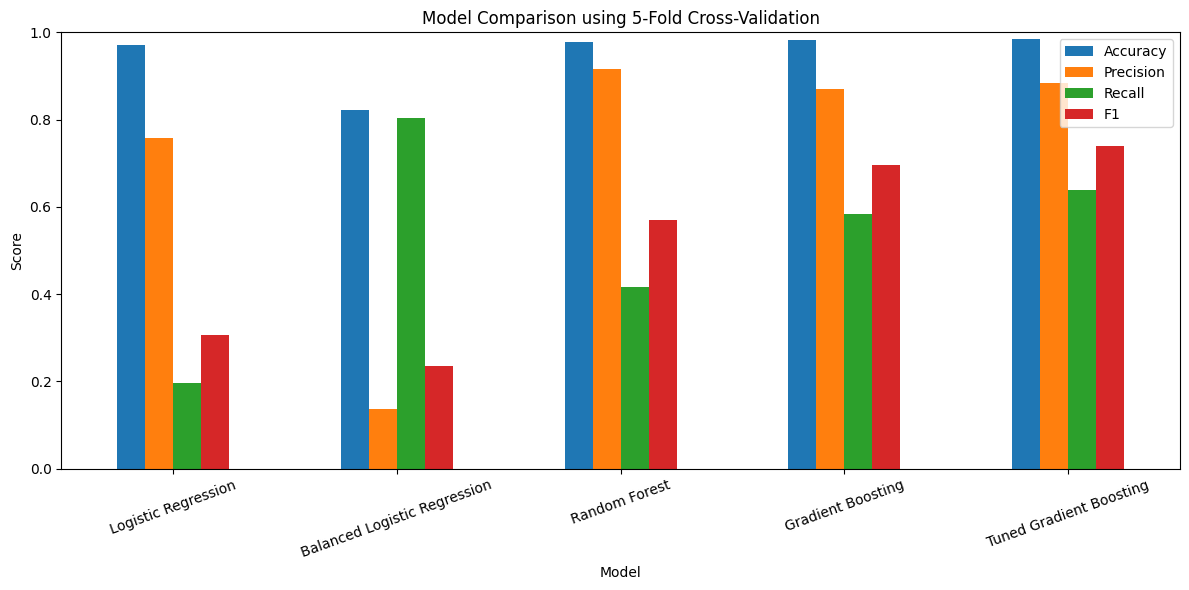

In [36]:
results_plot = results_df.set_index('Model')

results_plot[['Accuracy', 'Precision', 'Recall', 'F1']].plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title('Model Comparison using 5-Fold Cross-Validation')
plt.ylabel('Score')
plt.xlabel('Model')
plt.xticks(rotation=20)
plt.ylim(0, 1)

plt.legend()
plt.tight_layout()
plt.show()

In [37]:
import joblib

joblib.dump(best_gb, 'tuned_gradient_boosting_model.pkl')

print("Model saved successfully!")

Model saved successfully!


In [38]:
feature_names = list(X_train.columns)

joblib.dump(feature_names, 'feature_names.pkl')

print(feature_names)

['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Type_L', 'Type_M']


In [39]:
import joblib
import pandas as pd

# Load model and feature names
model = joblib.load('tuned_gradient_boosting_model.pkl')
feature_names = joblib.load('feature_names.pkl')


def predict_failure(air_temp, process_temp, rpm, torque, tool_wear, machine_type):
    
    # Encode machine type
    type_L = 1 if machine_type == 'L' else 0
    type_M = 1 if machine_type == 'M' else 0

    # Create input dataframe
    input_data = pd.DataFrame([[
        air_temp,
        process_temp,
        rpm,
        torque,
        tool_wear,
        type_L,
        type_M
    ]], columns=feature_names)

    # Prediction
    prediction = model.predict(input_data)[0]
    probability = model.predict_proba(input_data)[0][1]

    return prediction, probability

In [40]:
prediction, probability = predict_failure(
    air_temp=300,
    process_temp=310,
    rpm=1500,
    torque=40,
    tool_wear=100,
    machine_type='L'
)

print("Prediction:", prediction)
print("Failure Probability:", probability)

Prediction: 0
Failure Probability: 0.0013588548233167811


In [41]:
import os

print(os.getcwd())

C:\Users\Lenovo\prediction


In [42]:
required_columns = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
    "Type"
]

batch_test = df[required_columns].sample(
    20,
    random_state=42
).reset_index(drop=True)

batch_test.to_csv("batch_test.csv", index=False)

print(batch_test.shape)
print(batch_test.head())

(20, 6)
   Air temperature [K]  Process temperature [K]  Rotational speed [rpm]  \
0                300.8                    310.3                    1538   
1                303.6                    311.8                    1421   
2                298.3                    307.9                    1485   
3                303.3                    311.3                    1592   
4                302.4                    310.4                    1865   

   Torque [Nm]  Tool wear [min] Type  
0         36.1              198    L  
1         44.8              101    M  
2         42.0              117    M  
3         33.7               14    L  
4         23.9              129    L  


In [43]:
import os

print(os.getcwd())

C:\Users\Lenovo\prediction
